In [ ]:
# Colab link
# https://colab.research.google.com/drive/11DhAa9lx5LNFLHKDtSaWLhHkRfuDuMu5?usp=sharing

import pandas as pd
import os
import time
import matplotlib.pyplot as plt
from openai import OpenAI
from tqdm import tqdm
import json
from collections import defaultdict

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = ""  # Replace with your API key
client = OpenAI()

DATA_PATH = './data/synthea_sample_data_csv_latest/'

In [47]:
# Load the datasets
procedures_df = pd.read_csv(DATA_PATH + 'procedures.csv')
conditions_df = pd.read_csv(DATA_PATH + 'conditions.csv')

# Display basic information
print(f"Procedures dataset shape: {procedures_df.shape}")
print(f"Conditions dataset shape: {conditions_df.shape}")

# Sample of each dataset
print("\nProcedures Sample:")
display(procedures_df.head())

print("\nConditions Sample:")
display(conditions_df.head())

Procedures dataset shape: (17784, 10)
Conditions dataset shape: (3876, 7)

Procedures Sample:


,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2015-09-28T09:04:48Z,2015-09-28T09:34:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,953c5138-ce17-4084-3432-1ac23f184528,http://snomed.info/sct,713021002,Plain X-ray of pelvis (procedure),431.4,NaN,NaN
1,2015-09-28T09:04:48Z,2015-09-28T11:02:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,953c5138-ce17-4084-3432-1ac23f184528,http://snomed.info/sct,305428000,Admission to orthopedic department (procedure),431.4,359817006.0,Closed fracture of hip (disorder)
2,2016-04-10T09:04:48Z,2016-04-10T09:19:48Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,http://snomed.info/sct,430193006,Medication reconciliation (procedure),852.4,NaN,NaN
3,2016-04-10T09:04:48Z,2016-04-10T10:00:45Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,http://snomed.info/sct,710824005,Assessment of health and social care needs (pr...,431.4,NaN,NaN
4,2016-04-10T10:00:45Z,2016-04-10T10:22:03Z,30a6452c-4297-a1ac-977a-6a23237c7b46,0b03e41b-06a6-66fa-b972-acc5a83b134a,http://snomed.info/sct,710841007,Assessment of anxiety (procedure),431.4,NaN,NaN



Conditions Sample:


,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,105531004,Housing unsatisfactory (finding)
1,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,224299000,Received higher education (finding)
2,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,266934004,Transport problem (finding)
3,2012-04-01,NaN,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,422650009,Social isolation (finding)
4,2012-04-01,2016-04-10,30a6452c-4297-a1ac-977a-6a23237c7b46,294d0dab-907e-8fce-7a47-0c0d322a5734,http://snomed.info/sct,73595000,Stress (finding)


In [48]:
# Get unique patients and encounters
unique_patients = conditions_df['PATIENT'].nunique()
unique_encounters = conditions_df['ENCOUNTER'].nunique()

print(f"\nNumber of unique patients: {unique_patients}")
print(f"Number of unique encounters: {unique_encounters}")

# Top conditions
print("\nTop 10 most common conditions:")
display(conditions_df['DESCRIPTION'].value_counts().head(10))

# Top procedures
print("\nTop 10 most common procedures:")
display(procedures_df['DESCRIPTION'].value_counts().head(10))


Number of unique patients: 106
Number of unique encounters: 2542

Top 10 most common conditions:


DESCRIPTION
Medication review due (situation)    831
Gingivitis (disorder)                328
Stress (finding)                     295
Full-time employment (finding)       273
Part-time employment (finding)       167
Social isolation (finding)           110
Gingival disease (disorder)           93
Limited social contact (finding)      92
Viral sinusitis (disorder)            91
Not in labor force (finding)          90
Name: count, dtype: int64


Top 10 most common procedures:


DESCRIPTION
Depression screening (procedure)                                                                   1817
Renal dialysis (procedure)                                                                         1745
Assessment of health and social care needs (procedure)                                             1093
Medication reconciliation (procedure)                                                               788
Assessment of substance use (procedure)                                                             738
Patient referral for dental care (procedure)                                                        683
Dental consultation and report (procedure)                                                          678
Oral health education (procedure)                                                                   650
Dental care (regime/therapy)                                                                        645
Removal of supragingival plaque and calculus from al

In [49]:
encounter_to_procedures = {}
for encounter, group in procedures_df.groupby('ENCOUNTER'):
    encounter_to_procedures[encounter] = group['DESCRIPTION'].tolist()

# Group conditions by patient and encounter
patient_conditions = defaultdict(lambda: defaultdict(list))
for _, row in conditions_df.iterrows():
    patient_id = row['PATIENT']
    encounter_id = row['ENCOUNTER']
    patient_conditions[patient_id][encounter_id].append(row['DESCRIPTION'])

# Add procedures to encounters
encounter_data = []
for patient_id, encounters in patient_conditions.items():
    for encounter_id, conditions in encounters.items():
        if encounter_id in encounter_to_procedures:
            procedures = encounter_to_procedures[encounter_id]
            if procedures:  # Only include if there are procedures
                encounter_data.append({
                    'patient_id': patient_id,
                    'encounter_id': encounter_id,
                    'conditions': conditions,
                    'procedures': procedures
                })

print(f"Created {len(encounter_data)} encounter records with both conditions and procedures")

# Sample to see the relationship
print("\nSample encounter data:")
for i, sample in enumerate(encounter_data[:3]):
    print(f"\nSample {i+1}:")
    print(f"Patient ID: {sample['patient_id']}")
    print(f"Encounter ID: {sample['encounter_id']}")
    print(f"Conditions ({len(sample['conditions'])}):")
    for cond in sample['conditions'][:5]:  # Show first 5 conditions
        print(f"  - {cond}")
    if len(sample['conditions']) > 5:
        print(f"  ... {len(sample['conditions'])-5} more conditions")
    print(f"Procedures ({len(sample['procedures'])}):")
    for proc in sample['procedures'][:5]:  # Show first 5 procedures
        print(f"  - {proc}")
    if len(sample['procedures']) > 5:
        print(f"  ... {len(sample['procedures'])-5} more procedures")

Created 1642 encounter records with both conditions and procedures

Sample encounter data:

Sample 1:
Patient ID: 30a6452c-4297-a1ac-977a-6a23237c7b46
Encounter ID: 953c5138-ce17-4084-3432-1ac23f184528
Conditions (2):
  - Fracture of bone (disorder)
  - Closed fracture of hip (disorder)
Procedures (2):
  - Plain X-ray of pelvis (procedure)
  - Admission to orthopedic department (procedure)

Sample 2:
Patient ID: 30a6452c-4297-a1ac-977a-6a23237c7b46
Encounter ID: 0b03e41b-06a6-66fa-b972-acc5a83b134a
Conditions (3):
  - Limited social contact (finding)
  - Victim of intimate partner abuse (finding)
  - Gingivitis (disorder)
Procedures (9):
  - Medication reconciliation (procedure)
  - Assessment of health and social care needs (procedure)
  - Assessment of anxiety (procedure)
  - Screening for domestic abuse (procedure)
  - Depression screening (procedure)
  ... 4 more procedures

Sample 3:
Patient ID: 30a6452c-4297-a1ac-977a-6a23237c7b46
Encounter ID: 0aa3ec19-bcbd-3fb7-afc7-cf398aa417a

Created inference sample with 100 examples


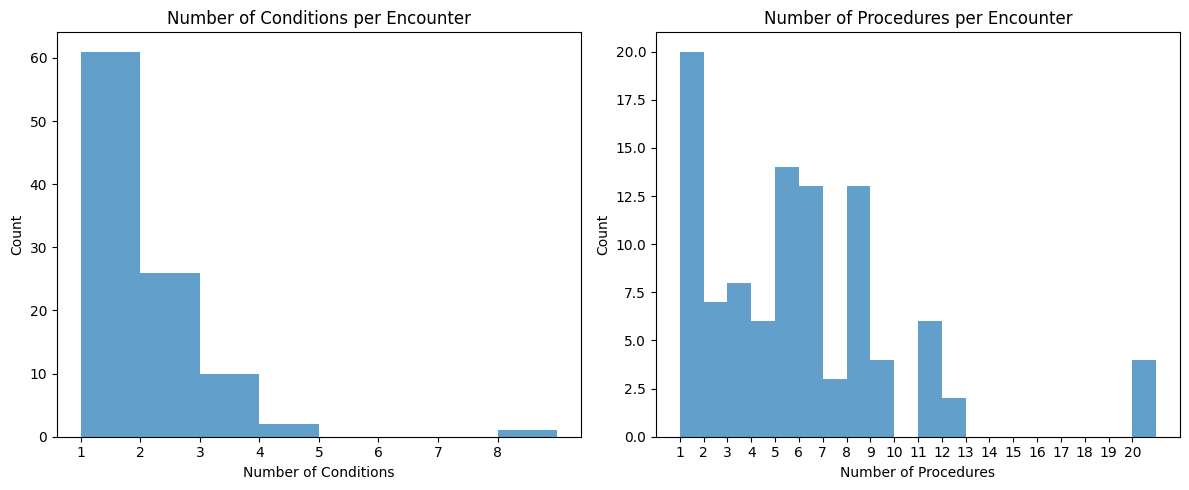

In [50]:
# Shuffle and take a sample for testing
import random
random.seed(42)
random.shuffle(encounter_data)

# Use a smaller sample size for initial testing
sample_size = 100  # Adjust based on your API usage limits
inference_sample = encounter_data[:sample_size]

print(f"Created inference sample with {len(inference_sample)} examples")

# Analyze sample distribution
condition_counts = [len(item['conditions']) for item in inference_sample]
procedure_counts = [len(item['procedures']) for item in inference_sample]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(condition_counts, bins=range(1, max(condition_counts)+2), alpha=0.7)
plt.title('Number of Conditions per Encounter')
plt.xlabel('Number of Conditions')
plt.ylabel('Count')
plt.xticks(range(1, max(condition_counts)+1))

plt.subplot(1, 2, 2)
plt.hist(procedure_counts, bins=range(1, max(procedure_counts)+2), alpha=0.7)
plt.title('Number of Procedures per Encounter')
plt.xlabel('Number of Procedures')
plt.ylabel('Count')
plt.xticks(range(1, max(procedure_counts)+1))

plt.tight_layout()
plt.show()

In [51]:
def zero_shot_prompt(conditions):
    # Format the list of conditions as a bulleted list
    conditions_text = "\n".join([f"- {condition}" for condition in conditions])
    
    return f"""Given the following patient's medical diagnoses/conditions, predict the most likely SNOMED procedures that would be performed to address these conditions. List up to 5-10 procedures that are most relevant. Do not provide any additional context, only list the name of the SNOMED procedures in a list.

    Patient Conditions:
    {conditions_text}


    Based on these conditions, the most likely procedures are:"""

def few_shot_prompt(conditions):
    conditions_text = "\n".join([f"- {condition}" for condition in conditions])
    return f"""
Given the following patient's medical diagnoses/conditions, predict the most likely SNOMED procedures that would be performed to address these conditions. List up to 5-10 procedures that are most relevant. Do not provide any additional context, only list the name of the SNOMED procedures in a list. For each example, I'll provide a list of conditions and the corresponding procedures:\n\n"

Here are 3 examples:

Example 1:

Input:
Conditions:
Diabetes mellitus type 2
Hypertension
Diabetic nephropathy

Output:
Diabetes mellitus management
Hypertension monitoring
Kidney function test
Hemoglobin A1c measurement
Urinalysis
Blood pressure taking
Diabetic retinopathy screening
Prescription of antihypertensive
Prescription of antidiabetic medication
Diabetic foot examination

Example 2:

Streptococcal pharyngitis
Fever
Difficulty swallowing

Output:
Throat swab for rapid strep test
Throat culture
Medication administration - analgesic
Medication administration - antipyretic
Penicillin administration
Patient education
Dietary recommendations
Follow-up appointment scheduling
Complete blood count

Example 3:

Input:
Conditions:
Chronic obstructive pulmonary disease
Wheezing
Chronic bronchitis

Output:
Pulmonary function test
Oxygen administration by mask
Oxygen administration by nasal cannula
Nebulizer therapy
Bronchodilator therapy
Sputum examination
Plain chest X-ray
Smoking cessation education
Corticosteroid therapy
Follow-up appointment scheduling

Patient Conditions:
{conditions_text}

Based on these conditions, the most likely procedures are:"""
def chain_of_thought_prompt(conditions):
    # Format the list of conditions as a bulleted list
    conditions_text = "\n".join([f"- {condition}" for condition in conditions])
    
    return f"""
Given the following patient's medical diagnoses/conditions, predict the most likely SNOMED procedures that would be performed to address these conditions. List up to 5-10 procedures that are most relevant. Do not provide any additional context, only list the name of the SNOMED procedures in a list. Think step by step about what procedures are typically used to treat or diagnose these conditions.

Use the following Chain of Thought process:

1. First, identify and categorize all patient conditions by body system and severity
2. For each condition, consider standard diagnostic procedures
3. For each condition, consider evidence-based treatment procedures
4. For each condition, consider monitoring and follow-up procedures
5. Consider interactions between conditions that might require additional procedures
6. Prioritize procedures based on clinical urgency and standard of care
7. Select the 5-10 most relevant procedure codes, ensuring no redundancy

Example:

Input:
Conditions:
Diabetes mellitus type 2
Hypertension
Diabetic nephropathy

Chain of Thought:

1. Condition Analysis:
   - Diabetes mellitus type 2 (44054006): Endocrine system, chronic, requires regular monitoring
   - Hypertension (38341003): Cardiovascular system, chronic, requires monitoring and management
   - Diabetic nephropathy (230690007): Renal complication of diabetes, indicates disease progression

2. Diagnostic Procedures:
   - For diabetes: HbA1c measurement, blood glucose testing
   - For hypertension: Blood pressure measurement, cardiac assessment
   - For diabetic nephropathy: Kidney function tests, urinalysis, microalbuminuria testing

3. Treatment Procedures:
   - For diabetes: Medication management, dietary counseling
   - For hypertension: Antihypertensive therapy, medication adjustment
   - For diabetic nephropathy: ACE inhibitor prescription, renal protective strategies

4. Monitoring Procedures:
   - Regular blood pressure monitoring
   - Kidney function monitoring
   - Comprehensive foot examination (due to diabetes)
   - Retinal examination (due to diabetes)

5. Interaction Considerations:
   - Diabetes and hypertension together increase cardiovascular risk, warranting cardiovascular assessment
   - Nephropathy suggests need for closer monitoring of both diabetes and hypertension
   - Medication interactions must be considered when treating multiple conditions

6. Prioritization:
   - Kidney function assessment is high priority due to nephropathy
   - Blood glucose and HbA1c control are essential for both diabetes and to prevent nephropathy progression
   - Cardiovascular risk assessment is important due to combined conditions

7. Selected Procedure Codes:
   - 310459008: Diabetes mellitus management
   - 390906007: Hypertension monitoring
   - 14698002: Kidney function test
   - 252275004: Hemoglobin A1c measurement
   - 43396009: Urinalysis
   - 46973005: Blood pressure taking
   - 134395001: Diabetic retinopathy screening
   - 698346001: Prescription of antihypertensive
   - 698085007: Prescription of antidiabetic medication
   - 171207006: Diabetic foot examination

Output:
Based on the patient's conditions of Type 2 Diabetes Mellitus, Hypertension, and Diabetic Nephropathy, the following 10 SNOMED procedure codes are recommended:

Diabetes mellitus management
Hypertension monitoring
Kidney function test
Hemoglobin A1c measurement
Urinalysis
Blood pressure taking
Diabetic retinopathy screening
Prescription of antihypertensive
Prescription of antidiabetic medication
Diabetic foot examination

Patient Conditions:
{conditions_text}

1. First, identify and categorize all patient conditions by body system and severity
2. For each condition, consider standard diagnostic procedures
3. For each condition, consider evidence-based treatment procedures
4. For each condition, consider monitoring and follow-up procedures
5. Consider interactions between conditions that might require additional procedures
6. Prioritize procedures based on clinical urgency and standard of care
7. Select the 5-10 most relevant procedure codes, ensuring no redundancy

Based on this reasoning, the most likely procedures are:"""

def tree_of_thought_prompt(conditions):
    # Format the list of conditions as a bulleted list
    conditions_text = "\n".join([f"- {condition}" for condition in conditions])
    
    return f"""
Given the following patient's medical diagnoses/conditions, predict the most likely SNOMED procedures that would be performed to address these conditions. List up to 5-10 procedures that are most relevant. Do not provide any additional context, only list the name of the SNOMED procedures in a list. Below is an example of how you might consider the procedures needed for each condition:

Use a Tree of Thought approach to explore multiple reasoning paths before reaching your final recommendation:

Example:

Input:
Streptococcal pharyngitis
Fever
Difficulty swallowing

Tree of Thought:

Path A: Focus on diagnostic procedures for streptococcal pharyngitis
- First, we need to confirm the diagnosis of strep throat.
- Throat swab for rapid strep test (SNOMED: 269936008)
- Throat culture for definitive diagnosis (SNOMED: 117015009)
- Complete blood count to check for infection (SNOMED: 26604007)
- Advantages: Essential for confirming diagnosis
- Disadvantages: May delay treatment if severe symptoms

Path B: Focus on symptomatic treatment procedures
- Pain and fever management is important
- Medication administration - analgesic (SNOMED: 18629005)
- Medication administration - antipyretic (SNOMED: 432798002)
- Intravenous fluid therapy if dehydrated (SNOMED: 61799000)
- Advantages: Addresses immediate patient discomfort
- Disadvantages: Doesn't address underlying infection

Path C: Focus on antibiotic treatment procedures
- Given confirmed streptococcal infection, antibiotics are needed
- Penicillin administration (SNOMED: 311866005)
- Alternative antibiotic administration for penicillin-allergic patients (SNOMED: 311870002)
- Advantages: Treats underlying bacterial cause
- Disadvantages: Not appropriate if viral cause suspected

Path D: Focus on prevention of complications
- Streptococcal pharyngitis can lead to complications
- Patient education (SNOMED: 311401005)
- Follow-up appointment scheduling (SNOMED: 390906007)
- Advantages: Helps prevent rheumatic fever and other complications
- Disadvantages: Not addressing immediate symptoms

Path E: Focus on dysphagia (difficulty swallowing)
- Swallowing assessment (SNOMED: 225398008)
- Dietary recommendations (SNOMED: 225406003)
- Advantages: Addresses specific symptom that impacts recovery
- Disadvantages: Secondary to treating the infection

Integration of paths:
The most appropriate approach combines diagnostic confirmation (Path A) with symptomatic treatment (Path B) followed by definitive treatment (Path C) and prevention (Path D).

For the difficulty swallowing, dietary modifications (Path E) should be included but aren't the primary focus.

Final Procedure Code Selection:
1. Throat swab for rapid strep test (from Path A)
2. Throat culture (from Path A)
3. Medication administration - analgesic (from Path B)
4. Medication administration - antipyretic (from Path B)
5. Penicillin administration (from Path C)
6. Patient education (from Path D)
7. Dietary recommendations (from Path E)
8. Follow-up appointment scheduling (from Path D)
9. Complete blood count (from Path A)

Output:
Throat swab for rapid strep test
Throat culture
Medication administration - analgesic
Medication administration - antipyretic
Penicillin administration
Patient education
Dietary recommendations
Follow-up appointment scheduling
Complete blood count

Patient Conditions:
{conditions_text}

Let me consider the procedures needed for each condition:

CONDITION ANALYSIS:
[For each condition, what procedures might be appropriate and why]

PROCEDURE CONSIDERATION:
1. [First possible procedure]: [Reasoning for why this might be appropriate]
2. [Second possible procedure]: [Reasoning for why this might be appropriate]
3. [Third possible procedure]: [Reasoning for why this might be appropriate]
4. [Fourth possible procedure]: [Reasoning for why this might be appropriate]
5. [Fifth possible procedure]: [Reasoning for why this might be appropriate]

After considering these possibilities, the most likely procedures are:"""

In [52]:
def get_model_inference(prompt, model="gpt-4o-mini"):
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "user", "content": prompt}
            ],
            max_tokens=250,  # Increased for handling multiple conditions/procedures
            temperature=0
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Error calling OpenAI API: {e}")
        time.sleep(5)  # Rate limit handling
        return "Error: Could not get response from model"

In [53]:
# Define the prompting strategies to test
strategies = {
    "zero_shot": zero_shot_prompt,
    "few_shot": few_shot_prompt,
    "chain_of_thought": chain_of_thought_prompt,
    "tree_of_thought": tree_of_thought_prompt
}

# Run inference for each strategy
results = {}

for strategy_name, prompt_func in strategies.items():
    print(f"\nRunning inference with {strategy_name} prompting...")
    strategy_results = []
    
    for item in tqdm(inference_sample):
        prompt = prompt_func(item['conditions'])
        inference = get_model_inference(prompt)
        
        strategy_results.append({
            'encounter_id': item['encounter_id'],
            'patient_id': item['patient_id'],
            'conditions': item['conditions'],
            'actual_procedures': item['procedures'],
            'predicted_procedures': inference,
            'prompt': prompt
        })
        
        # Sleep to avoid rate limits
        time.sleep(1)
    
    results[strategy_name] = strategy_results
    
    # Save intermediate results to avoid losing progress
    with open(f"{strategy_name}_results.json", "w") as f:
        json.dump(strategy_results, f, indent=2)

print("Inference complete for all strategies")


Running inference with zero_shot prompting...


100%|██████████| 100/100 [04:09<00:00,  2.50s/it]



Running inference with few_shot prompting...


100%|██████████| 100/100 [04:14<00:00,  2.54s/it]



Running inference with chain_of_thought prompting...


100%|██████████| 100/100 [05:24<00:00,  3.25s/it]



Running inference with tree_of_thought prompting...


100%|██████████| 100/100 [07:37<00:00,  4.57s/it]

Inference complete for all strategies


In [54]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Function to extract procedures from model response
def extract_procedures(response_text):
    # Try numbered list pattern with codes (e.g., "1. 225100002 - Counseling for stress management")
    numbered_code_pattern = r"\d+\.?\s+\d+\s*-\s+(.*?)(?=\n\d+\.?|\n\n|$)"
    numbered_with_codes = re.findall(numbered_code_pattern, response_text, re.DOTALL)
    if numbered_with_codes:
        return [item.strip() for item in numbered_with_codes]
    
    # Try numbered list pattern without codes (most common in your results)
    numbered_pattern = r"\d+\.?\s+(.*?)(?=\n\d+\.?|\n\n|$)"
    numbered = re.findall(numbered_pattern, response_text, re.DOTALL)
    if numbered:
        return [item.strip() for item in numbered]
    
    # Try bullets if no numbered list
    bullet_pattern = r"[-•*] (.*?)(?=\n[-•*]|\n\n|$)"
    bullets = re.findall(bullet_pattern, response_text, re.DOTALL)
    if bullets:
        return [bullet.strip() for bullet in bullets]
    
    # Fall back to lines after phrases like "procedures are:"
    lines = [line.strip() for line in response_text.split('\n') if line.strip()]
    for i, line in enumerate(lines):
        if any(phrase in line.lower() for phrase in ["procedures are:", "procedures:", "likely procedures:"]):
            return [l.strip() for l in lines[i+1:] if l.strip()]
    
    return lines

# Alternative function to extract procedures that handles codes
def extract_procedures_with_codes(response_text):
    # Initialize empty list for procedures
    procedures = []
    
    # Split the text into lines
    lines = [line.strip() for line in response_text.split('\n') if line.strip()]
    
    # Process each line
    for line in lines:
        # Match patterns like "1. 225100002 - Counseling for stress management"
        code_match = re.match(r"\d+\.?\s+(\d+)\s*-\s+(.*)", line)
        if code_match:
            procedure_name = code_match.group(2).strip()
            procedures.append(procedure_name)
            continue
        
        # Match patterns like "1. Oral examination (SNOMED: 271442004)"
        snomed_match = re.match(r"\d+\.?\s+(.*?)\s*\(SNOMED:\s*\d+\)", line)
        if snomed_match:
            procedure_name = snomed_match.group(1).strip()
            procedures.append(procedure_name)
            continue
            
        # Match regular numbered items without codes but with possible parenthetical content
        numbered_match = re.match(r"\d+\.?\s+(.*?)(?:\s*\([^)]*\)|$)", line)
        if numbered_match:
            procedure_name = numbered_match.group(1).strip()
            procedures.append(procedure_name)
            continue
            
        # Match bullet points
        bullet_match = re.match(r"[-•*]\s+(.*?)(?:\s*\([^)]*\)|$)", line)
        if bullet_match:
            procedure_name = bullet_match.group(1).strip()
            procedures.append(procedure_name)
    
    return procedures

# Function to clean text for better matching
def clean_text(text):
    # Simple text cleaning - lowercase and remove some common words
    text = text.lower()
    # Remove common procedure words that don't affect matching
    text = text.replace(" procedure", "")
    text = text.replace("procedure ", "")
    text = text.replace(" of ", " ")
    text = text.replace(" for ", " ")
    text = text.replace(" and ", " ")
    text = text.replace(" with ", " ")
    text = text.replace(" the ", " ")
    text = text.replace("(", "").replace(")", "")
    return text

# Function to calculate partial match score between two procedures
def partial_match_score(pred, actual, threshold=0.5):
    pred = clean_text(pred)
    actual = clean_text(actual)
    
    # Direct string matching
    if pred == actual:
        return 1.0
    
    # Check if one is a substring of the other
    if pred in actual or actual in pred:
        return 0.8
        
    # Calculate word overlap - simple version
    pred_words = set(pred.split())
    actual_words = set(actual.split())
    
    if not pred_words or not actual_words:
        return 0.0
        
    # Jaccard similarity
    intersection = len(pred_words.intersection(actual_words))
    union = len(pred_words.union(actual_words))
    
    score = intersection / union if union > 0 else 0.0
    return score if score >= threshold else 0.0

# Function to evaluate predictions for a single example
def evaluate_prediction(predicted_procs, actual_procs, threshold=0.5):
    matches = 0
    matched_actuals = set()
    
    for pred in predicted_procs:
        best_score = 0
        best_match = None
        
        for actual in actual_procs:
            score = partial_match_score(pred, actual, threshold)
            if score > best_score:
                best_score = score
                best_match = actual
        
        if best_score > 0:
            matches += 1
            matched_actuals.add(best_match)
    
    # Calculate precision, recall, F1
    precision = matches / len(predicted_procs) if predicted_procs else 0
    recall = len(matched_actuals) / len(actual_procs) if actual_procs else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'matches': matches,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Function to evaluate an entire prompting strategy
def evaluate_strategy(results):
    metrics = []
    
    for item in results:
        # Get or extract procedures
        if 'extracted_procedures' in item:
            predicted = item['extracted_procedures']
        else:
            # Use the new extraction function to handle codes
            predicted = extract_procedures_with_codes(item['predicted_procedures'])
        
        actual = item['actual_procedures']
        
        # Skip empty predictions or actuals
        if not predicted or not actual:
            continue
            
        # Get metrics for this example
        eval_result = evaluate_prediction(predicted, actual)
        metrics.append(eval_result)
    
    # Calculate averages
    avg_precision = np.mean([m['precision'] for m in metrics])
    avg_recall = np.mean([m['recall'] for m in metrics])
    avg_f1 = np.mean([m['f1'] for m in metrics])
    
    return {
        'precision': avg_precision,
        'recall': avg_recall,
        'f1': avg_f1,
        'sample_size': len(metrics)
    }

# Function to evaluate and compare multiple strategies
def compare_strategies(results_dict):
    comparison = {}
    
    for strategy, results in results_dict.items():
        print(f"Evaluating {strategy}...")
        comparison[strategy] = evaluate_strategy(results)
    
    # Convert to DataFrame for easy display
    df = pd.DataFrame.from_dict(comparison, orient='index')
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    
    # Create the bar plot
    ax = df[['precision', 'recall', 'f1']].plot(kind='bar')
    
    # Adjust y-axis to ensure visibility of very small values
    # Set minimum to a small positive value instead of 0
    plt.ylim(0.0005, 1)
    
    # Use log scale for better visibility of small values
    plt.yscale('log')
    
    # Add horizontal grid lines at appropriate intervals for log scale
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)
    
    plt.title('Comparison of Prompting Strategies (Log Scale)')
    plt.ylabel('Score (Log Scale)')
    plt.xlabel('Strategy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return df

Loaded 100 examples for zero_shot
Loaded 100 examples for few_shot
Loaded 100 examples for chain_of_thought
Loaded 100 examples for tree_of_thought

Example evaluation:
Conditions: ['Stress (finding)', 'Gingivitis (disorder)']
Predicted procedures: ['Counseling for stress management', 'Oral hygiene instruction', 'Scaling and root planing', 'Dental prophylaxis', 'Periodontal maintenance', 'Fluoride treatment', 'Antimicrobial therapy for gingivitis', 'Patient education on gingivitis prevention', 'Dental examination', 'Periodontal evaluation']
Actual procedures: ['Assessment of health and social care needs (procedure)', 'Screening for domestic abuse (procedure)', 'Depression screening (procedure)', 'Depression screening (procedure)', 'Patient referral for dental care (procedure)']
Matches found: 0
Precision: 0.00
Recall: 0.00
F1 score: 0.00

Comparing all prompting strategies...
Evaluating zero_shot...
Evaluating few_shot...
Evaluating chain_of_thought...
Evaluating tree_of_thought...


<Figure size 1000x600 with 0 Axes>

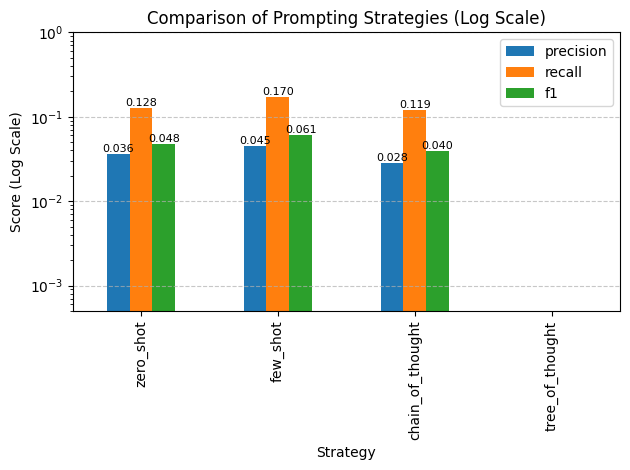


Strategy comparison results:


,precision,recall,f1,sample_size
zero_shot,0.036,0.127510,0.047818,100
few_shot,0.045,0.170303,0.061368,100
chain_of_thought,0.028,0.119482,0.039770,100
tree_of_thought,0.000,0.000000,0.000000,100



Showing matching examples from the best strategy (few_shot):

Examples of procedure matches:

Conditions: ['Medication review due (situation)']
Matched procedures:
Predicted: 'Medication reconciliation' → Actual: 'Medication reconciliation (procedure)' (Score: 0.80)

Conditions: ['Medication review due (situation)']
Matched procedures:
Predicted: 'Medication reconciliation' → Actual: 'Medication reconciliation (procedure)' (Score: 0.80)


In [55]:
import json

# Load your results files
def load_results(file_path):
    with open(file_path, "r") as f:
        return json.load(f)

# Load all strategies' results
strategies = {
    "zero_shot": "./zero_shot_results.json",
    "few_shot": "./few_shot_results.json",
    "chain_of_thought": "./chain_of_thought_results.json",
    "tree_of_thought": "./tree_of_thought_results.json"
}

results = {}
for strategy, file_path in strategies.items():
    results[strategy] = load_results(file_path)
    print(f"Loaded {len(results[strategy])} examples for {strategy}")

# Extract procedures for all examples
for strategy, strategy_results in results.items():
    for item in strategy_results:
        item['extracted_procedures'] = extract_procedures(item['predicted_procedures'])

# Example of evaluating a single prediction
example = results["zero_shot"][0]
eval_result = evaluate_prediction(example['extracted_procedures'], example['actual_procedures'])
print("\nExample evaluation:")
print(f"Conditions: {example['conditions']}")
print(f"Predicted procedures: {example['extracted_procedures']}")
print(f"Actual procedures: {example['actual_procedures']}")
print(f"Matches found: {eval_result['matches']}")
print(f"Precision: {eval_result['precision']:.2f}")
print(f"Recall: {eval_result['recall']:.2f}")
print(f"F1 score: {eval_result['f1']:.2f}")

# Compare all strategies
print("\nComparing all prompting strategies...")
comparison_df = compare_strategies(results)
print("\nStrategy comparison results:")
display(comparison_df)

# Show some examples of matches and mismatches
def show_matching_examples(strategy_results, n=2):
    print("\nExamples of procedure matches:")
    
    for item in strategy_results[:10]:  # Check first 10 items
        predicted = item['extracted_procedures']
        actual = item['actual_procedures']
        
        # Find matches
        matches = []
        for pred in predicted:
            for act in actual:
                score = partial_match_score(pred, act)
                if score > 0:
                    matches.append((pred, act, score))
        
        if matches:
            print(f"\nConditions: {item['conditions']}")
            print("Matched procedures:")
            for pred, act, score in matches[:3]:  # Show up to 3 matches
                print(f"Predicted: '{pred}' → Actual: '{act}' (Score: {score:.2f})")
            
            n -= 1
            if n <= 0:
                break

# Show examples of matches from the best strategy
best_strategy = comparison_df['f1'].idxmax()
print(f"\nShowing matching examples from the best strategy ({best_strategy}):")
show_matching_examples(results[best_strategy])